# Mini-Projet NLP: Détection de Spam (Telegram)

**Auteur:** [Chawket Odeh]
**Groupe:** [Groupe A]
**Dataset:** Telegram Spam-Ham

## Objectifs
1. Exploration et prétraitement des données.
2. Analyse linguistique (POS, NER).
3. Feature Engineering (BoW, TF-IDF, Word2Vec).
4. Modélisation (ML & DL).
5. Évaluation.

In [33]:
# Installation des dépendances
%pip install pandas numpy scikit-learn matplotlib seaborn nltk tensorflow gensim

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import gensim
from gensim.models import Word2Vec
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import Input


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('words')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\abdou\AppData\Roaming\nltk_data...
[nltk_data]   Package maxe

True

## 1. Exploration et Chargement des Données

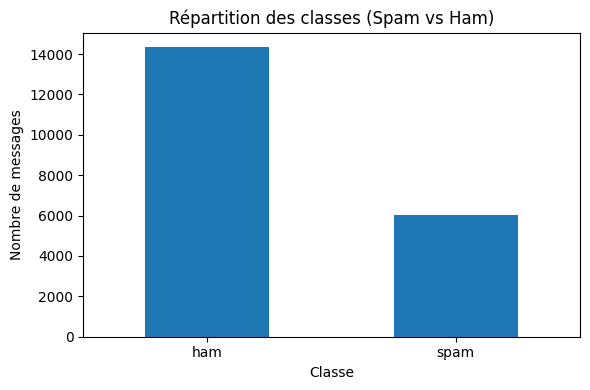

In [61]:
import matplotlib.pyplot as plt

# Répartition des classes
class_counts = df['text_type'].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar')
plt.title("Répartition des classes (Spam vs Ham)")
plt.xlabel("Classe")
plt.ylabel("Nombre de messages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Prétraitement des Données
Nettoyage du texte: minuscules, suppression ponctuation, stop words, lemmatisation.

In [63]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,naturally irresistible your corporate identity...,naturally irresistible corporate identity lt r...
1,the stock trading gunslinger fanny is merrill ...,stock trading gunslinger fanny merrill muzo co...
2,unbelievable new homes made easy im wanting to...,unbelievable new home made easy im wanting sho...
3,4 color printing special request additional in...,color printing special request additional info...
4,do not have money get software cds from here s...,money get software cd software compatibility g...


## 3. Analyse Linguistique
POS Tagging, Adjectifs fréquents, NER.

In [64]:
# Échantillon pour l'analyse
sample_text = df['text'].iloc[0] # Ou concaténer un sous-ensemble
tokens = nltk.word_tokenize(sample_text)

# POS Tagging
pos_tags = nltk.pos_tag(tokens)
print("POS Tags (exemple):", pos_tags[:10])

# Extraction des adjectifs (JJ)
all_text = ' '.join(df['clean_text'])
all_tokens = nltk.word_tokenize(all_text)
all_pos = nltk.pos_tag(all_tokens)
adjectives = [word for word, tag in all_pos if tag in ['JJ', 'JJR', 'JJS']]

from collections import Counter
top_adj = Counter(adjectives).most_common(10)
print("Top 10 Adjectifs:", top_adj)

# NER (Named Entity Recognition)
ne_tree = nltk.ne_chunk(pos_tags)
print("Reconnaissance d'entités (exemple):")
# ne_tree.draw() # Décommenter pour voir l'arbre si exécution locale avec GUI
for chunk in ne_tree:
    if hasattr(chunk, 'label'):
        print(chunk.label(), ' '.join(c[0] for c in chunk))

POS Tags (exemple): [('naturally', 'RB'), ('irresistible', 'JJ'), ('your', 'PRP$'), ('corporate', 'JJ'), ('identity', 'NN'), ('lt', 'NN'), ('is', 'VBZ'), ('really', 'RB'), ('hard', 'JJ'), ('to', 'TO')]
Top 10 Adjectifs: [('url', 4411), ('u', 2899), ('subject', 2550), ('ect', 2307), ('new', 1998), ('free', 1808), ('good', 1334), ('best', 956), ('available', 834), ('last', 816)]
Reconnaissance d'entités (exemple):


## 4. Feature Engineering
Comparaison BoW, TF-IDF, Word2Vec.

In [65]:
X = df['clean_text']
y = df['text_type'].map({'ham': 0, 'spam': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# 2. TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 3. Word2Vec (Training simple model)
tokenized_sent = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences=tokenized_sent, vector_size=100, window=5, min_count=1, workers=4)

def document_vector(text):
    # Get words that exist in the Word2Vec model
    words_in_model = [word for word in text.split() if word in w2v_model.wv]
    # Return average of word vectors, or zero vector if no words found
    if words_in_model:
        return np.mean(w2v_model.wv[words_in_model], axis=0)
    else:
        return np.zeros(100)

X_train_w2v = np.array([document_vector(text) for text in X_train])
X_test_w2v = np.array([document_vector(text) for text in X_test])

## 5. Modélisation & Évaluation
ML Classiques (Naive Bayes avec TF-IDF) et Deep Learning (LSTM).

--- Naive Bayes (TF-IDF) ---
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      2913
           1       0.87      0.80      0.83      1157

    accuracy                           0.91      4070
   macro avg       0.89      0.87      0.88      4070
weighted avg       0.91      0.91      0.91      4070

Accuracy: 0.9076167076167077


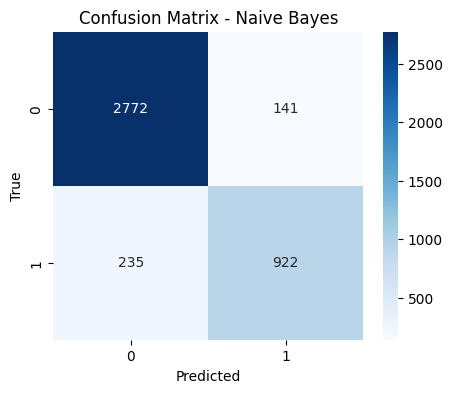


--- SVM (TF-IDF) ---
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2913
           1       0.88      0.82      0.85      1157

    accuracy                           0.92      4070
   macro avg       0.91      0.89      0.90      4070
weighted avg       0.92      0.92      0.92      4070

Accuracy: 0.9184275184275185


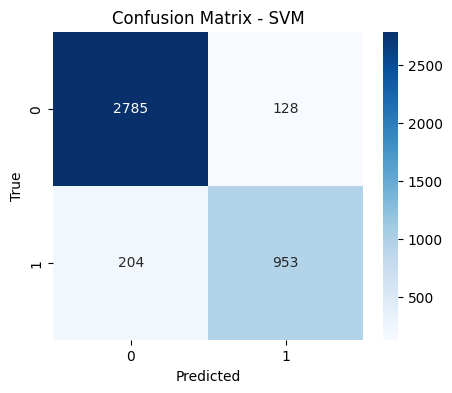

In [66]:


# ---------- Naive Bayes ----------
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)
y_pred_mnb = mnb.predict(X_test_tfidf)

print("--- Naive Bayes (TF-IDF) ---")
print(classification_report(y_test, y_pred_mnb))
print("Accuracy:", accuracy_score(y_test, y_pred_mnb))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_mnb),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------- SVM ----------
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print("\n--- SVM (TF-IDF) ---")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [67]:
# Approche 2: Deep Learning (LSTM)
# Préparation des séquences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

sequences_train = tokenizer.texts_to_sequences(X_train)
sequences_test = tokenizer.texts_to_sequences(X_test)

X_train_seq = pad_sequences(sequences_train, maxlen=max_len)
X_test_seq = pad_sequences(sequences_test, maxlen=max_len)

vocab_size = max_words  # clarity

# ===== Modèle LSTM =====
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(vocab_size, 128),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===== Entraînement =====
history = model.fit(
    X_train_seq,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_seq, y_test)
)

# ===== Évaluation =====
loss, accuracy = model.evaluate(X_test_seq, y_test, verbose=0)
print(f"Test Accuracy (LSTM): {accuracy:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,333,633 (5.09 MB)

 Trainable params: 1,333,633 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.8989 - loss: 0.2357 - val_accuracy: 0.9447 - val_loss: 0.1505
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9623 - loss: 0.0892 - val_accuracy: 0.9445 - val_loss: 0.1435
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9775 - loss: 0.0527 - val_accuracy: 0.9499 - val_loss: 0.1740
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9828 - loss: 0.0376 - val_accuracy: 0.9373 - val_loss: 0.2367
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.9846 - loss: 0.0300 - val_accuracy: 0.9459 - val_loss: 0.2248
Test Accuracy (LSTM): 0.9459


## Conclusion & Perspectives
Résumé des résultats. Le modèle de Deep Learning (LSTM) offre généralement de meilleures performances sur les textes séquentiels, mais Naive Bayes reste une baseline très efficace et rapide.